In [1]:
import pandas as pd
df = pd.read_csv("zameen-updated.csv")
df.head()


,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [2]:
# Keep only properties for sale (drop rentals)
df_sale = df[df['purpose'] == 'For Sale'].copy()
df_sale.shape

(120655, 20)

In [3]:
# How many properties have price = 0?
print("Zero price count:", (df_sale['price'] == 0).sum())

# Look at the most expensive properties
df_sale.sort_values('price', ascending=False).head(10)[['price', 'property_type', 'location', 'city', 'bedrooms', 'baths', 'area']]

Zero price count: 2


,price,property_type,location,city,bedrooms,baths,area
85499,2000000000,House,Mall Road,Lahore,11,10,19.2 Kanal
58032,1450000000,House,KDA Scheme 1,Karachi,8,8,6.1 Kanal
68867,1430000000,House,Gulberg,Lahore,8,9,13 Kanal
77087,1350000000,House,KDA Scheme 1,Karachi,5,6,6 Kanal
15320,1270000000,House,Gulberg,Lahore,0,0,6.4 Kanal
84,1250000000,House,Gulberg,Lahore,0,0,8 Kanal
74283,1250000000,House,Gulberg,Lahore,0,0,8 Kanal
312,1200000000,House,Gulberg,Lahore,0,0,8 Kanal
95572,1000000000,House,Gulberg,Lahore,8,0,9 Kanal
55589,1000000000,House,Clifton,Karachi,11,10,4 Kanal


In [4]:
df_sale = df_sale[df_sale['price'] > 0].copy()
df_sale.shape

(120653, 20)

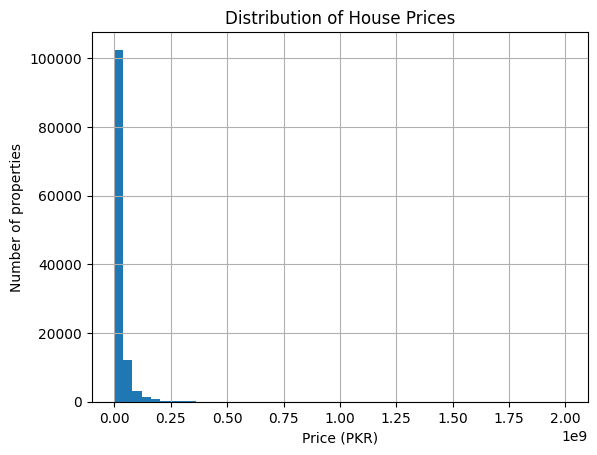

In [5]:
import matplotlib.pyplot as plt

df_sale['price'].hist(bins=50)
plt.xlabel('Price (PKR)')
plt.ylabel('Number of properties')
plt.title('Distribution of House Prices')
plt.show()

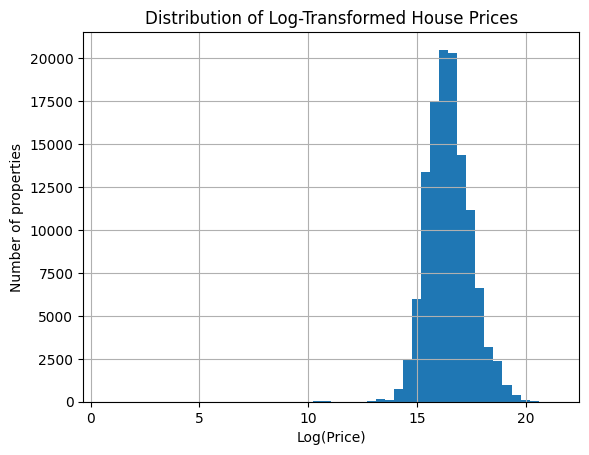

In [6]:
import numpy as np

df_sale['log_price'] = np.log1p(df_sale['price'])

df_sale['log_price'].hist(bins=50)
plt.xlabel('Log(Price)')
plt.ylabel('Number of properties')
plt.title('Distribution of Log-Transformed House Prices')
plt.show()

In [7]:
df_sale['property_type'].value_counts()

property_type
House            87975
Flat             28118
Upper Portion     2628
Lower Portion     1004
Farm House         608
Penthouse          295
Room                25
Name: count, dtype: int64

In [8]:
df_sale = df_sale[df_sale['property_type'].isin(['House', 'Flat'])].copy()
df_sale.shape

(116093, 21)

In [9]:
df_sale[['area', 'Area Type', 'Area Size', 'Area Category']].head(10)

,area,Area Type,Area Size,Area Category
0,4 Marla,Marla,4.0,0-5 Marla
1,5.6 Marla,Marla,5.6,5-10 Marla
2,8 Marla,Marla,8.0,5-10 Marla
3,2 Kanal,Kanal,2.0,1-5 Kanal
4,8 Marla,Marla,8.0,5-10 Marla
5,1.6 Kanal,Kanal,1.6,1-5 Kanal
6,1 Kanal,Kanal,1.0,1-5 Kanal
7,6.2 Marla,Marla,6.2,5-10 Marla
8,1 Kanal,Kanal,1.0,1-5 Kanal
10,7.1 Marla,Marla,7.1,5-10 Marla


In [10]:
df_sale['Area Type'].value_counts()

Area Type
Marla    98258
Kanal    17835
Name: count, dtype: int64

In [11]:
def convert_to_marla(row):
    if row['Area Type'] == 'Kanal':
        return row['Area Size'] * 20
    else:  # Already Marla
        return row['Area Size']

df_sale['area_marla'] = df_sale.apply(convert_to_marla, axis=1)

df_sale[['area', 'Area Type', 'Area Size', 'area_marla']].head(10)


,area,Area Type,Area Size,area_marla
0,4 Marla,Marla,4.0,4.0
1,5.6 Marla,Marla,5.6,5.6
2,8 Marla,Marla,8.0,8.0
3,2 Kanal,Kanal,2.0,40.0
4,8 Marla,Marla,8.0,8.0
5,1.6 Kanal,Kanal,1.6,32.0
6,1 Kanal,Kanal,1.0,20.0
7,6.2 Marla,Marla,6.2,6.2
8,1 Kanal,Kanal,1.0,20.0
10,7.1 Marla,Marla,7.1,7.1


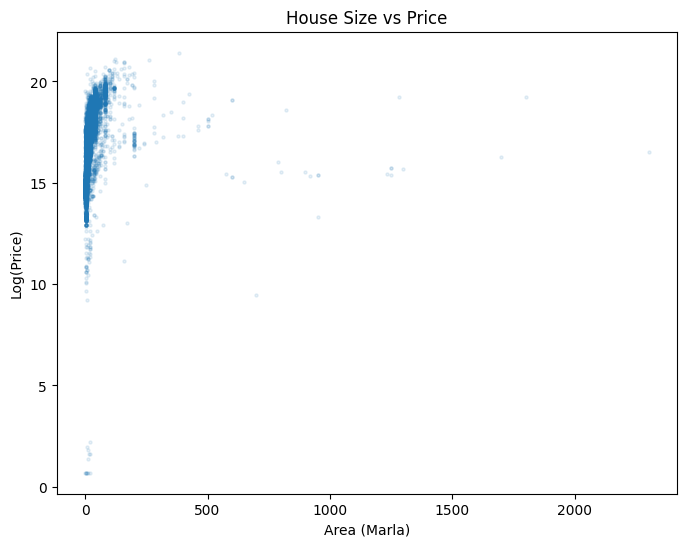

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(df_sale['area_marla'], df_sale['log_price'], alpha=0.1, s=5)
plt.xlabel('Area (Marla)')
plt.ylabel('Log(Price)')
plt.title('House Size vs Price')
plt.show()

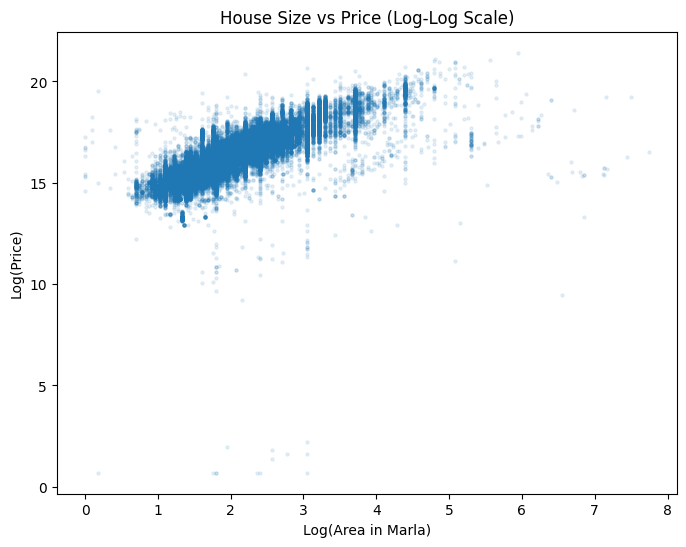

In [13]:
df_sale['log_area'] = np.log1p(df_sale['area_marla'])

plt.figure(figsize=(8,6))
plt.scatter(df_sale['log_area'], df_sale['log_price'], alpha=0.1, s=5)
plt.xlabel('Log(Area in Marla)')
plt.ylabel('Log(Price)')
plt.title('House Size vs Price (Log-Log Scale)')
plt.show()

In [14]:
# Remove unrealistic prices (too cheap to be real houses/flats)
df_sale = df_sale[df_sale['price'] > 100000].copy()

# Remove properties with 0 bedrooms or 0 bathrooms (likely bad data, not real houses)
df_sale = df_sale[(df_sale['bedrooms'] > 0) & (df_sale['baths'] > 0)].copy()

# Remove unrealistically huge outlier properties (keep it to reasonable homes)
df_sale = df_sale[df_sale['area_marla'] < 500].copy()

print("Final dataset shape:", df_sale.shape)
df_sale[['price', 'log_price', 'area_marla', 'log_area', 'bedrooms', 'baths', 'city']].describe()

Final dataset shape: (89642, 23)


,price,log_price,area_marla,log_area,bedrooms,baths
count,8.964200e+04,89642.000000,89642.000000,89642.000000,89642.000000,89642.000000
mean,2.470761e+07,16.509763,9.741175,2.148556,3.842328,4.040394
std,3.718033e+07,0.969646,10.889190,0.619133,1.592216,2.218658
min,1.250000e+05,11.736077,0.000000,0.000000,1.000000,1.000000
25%,7.500000e+06,15.830414,4.800000,1.757858,3.000000,3.000000
50%,1.400000e+07,16.454568,7.000000,2.079442,4.000000,4.000000
75%,2.650000e+07,17.092655,10.000000,2.397895,5.000000,5.000000
max,2.000000e+09,21.416413,460.000000,6.133398,16.000000,403.000000


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode text columns into numbers (models only understand numbers)
le_city = LabelEncoder()
le_type = LabelEncoder()

df_sale['city_encoded'] = le_city.fit_transform(df_sale['city'])
df_sale['property_type_encoded'] = le_type.fit_transform(df_sale['property_type'])

# Select our final features (inputs) and target (what we predict)
features = ['log_area', 'bedrooms', 'baths', 'city_encoded', 'property_type_encoded', 'latitude', 'longitude']
X = df_sale[features]
y = df_sale['log_price']

# Split into training (80%) and testing (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (71713, 7)
Test set: (17929, 7)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R² Score:", r2_score(y_test, predictions))
print("Mean Absolute Error (log scale):", mean_absolute_error(y_test, predictions))

R² Score: 0.6648352144108749
Mean Absolute Error (log scale): 0.3399454677581366


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest R² Score:", r2_score(y_test, rf_predictions))
print("Random Forest MAE (log scale):", mean_absolute_error(y_test, rf_predictions))

Random Forest R² Score: 0.9189334814023581
Random Forest MAE (log scale): 0.15787613403024436


In [18]:
importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

                 feature  importance
0               log_area    0.742445
5               latitude    0.102604
6              longitude    0.058427
1               bedrooms    0.050869
2                  baths    0.027782
4  property_type_encoded    0.015534
3           city_encoded    0.002340


In [ ]:
import joblib

joblib.dump(rf_model, 'house_price_model.pkl')
joblib.dump(le_city, 'city_encoder.pkl')
joblib.dump(le_type, 'property_type_encoder.pkl')

print("Model and encoders saved!")    property_id	location_id	page_url	property_type	price	location	city	province_name	latitude	longitude	baths	area	purpose	bedrooms	date_added	agency	agent	Area Type	Area Size	Area Category
0	237062	3325	https://www.zameen.com/Property/g_10_g_10_2_gr...	Flat	10000000	G-10	Islamabad	Islamabad Capital	33.679890	73.012640	2	4 Marla	For Sale	2	02-04-2019	NaN	NaN	Marla	4.0	0-5 Marla
1	346905	3236	https://www.zameen.com/Property/e_11_2_service...	Flat	6900000	E-11	Islamabad	Islamabad Capital	33.700993	72.971492	3	5.6 Marla	For Sale	3	05-04-2019	NaN	NaN	Marla	5.6	5-10 Marla
2	386513	764	https://www.zameen.com/Property/islamabad_g_15...	House	16500000	G-15	Islamabad	Islamabad Capital	33.631486	72.926559	6	8 Marla	For Sale	5	07-17-2019	NaN	NaN	Marla	8.0	5-10 Marla
3	656161	340	https://www.zameen.com/Property/islamabad_bani...	House	43500000	Bani Gala	Islamabad	Islamabad Capital	33.707573	73.151199	4	2 Kanal	For Sale	4	04-05-2019	NaN	NaN	Kanal	2.0	1-5 Kanal
4	841645	3226	https://www.zameen.com/Property/dha_valley_dha...	House	7000000	DHA Defence	Islamabad	Islamabad Capital	33.492591	73.301339	3	8 Marla	For Sale	3	07-10-2019	Easy Property	Muhammad Junaid Ceo Muhammad Shahid Director	Marla	8.0	5-10 Marla
Zero price count: 2
price	property_type	location	city	bedrooms	baths	area
85499	2000000000	House	Mall Road	Lahore	11	10	19.2 Kanal
58032	1450000000	House	KDA Scheme 1	Karachi	8	8	6.1 Kanal
68867	1430000000	House	Gulberg	Lahore	8	9	13 Kanal
77087	1350000000	House	KDA Scheme 1	Karachi	5	6	6 Kanal
15320	1270000000	House	Gulberg	Lahore	0	0	6.4 Kanal
84	1250000000	House	Gulberg	Lahore	0	0	8 Kanal
74283	1250000000	House	Gulberg	Lahore	0	0	8 Kanal
312	1200000000	House	Gulberg	Lahore	0	0	8 Kanal
95572	1000000000	House	Gulberg	Lahore	8	0	9 Kanal
55589	1000000000	House	Clifton	Karachi	11	10	4 Kanal
(120655, 20)
(120653, 20)
property_type
House            87975
Flat             28118
Upper Portion     2628
Lower Portion     1004
Farm House         608
Penthouse          295
Room                25
Name: count, dtype: int64
(116093, 21)
area	Area Type	Area Size	Area Category
0	4 Marla	Marla	4.0	0-5 Marla
1	5.6 Marla	Marla	5.6	5-10 Marla
2	8 Marla	Marla	8.0	5-10 Marla
3	2 Kanal	Kanal	2.0	1-5 Kanal
4	8 Marla	Marla	8.0	5-10 Marla
5	1.6 Kanal	Kanal	1.6	1-5 Kanal
6	1 Kanal	Kanal	1.0	1-5 Kanal
7	6.2 Marla	Marla	6.2	5-10 Marla
8	1 Kanal	Kanal	1.0	1-5 Kanal
10	7.1 Marla	Marla	7.1	5-10 Marla
Area Type
Marla    98258
Kanal    17835
Name: count, dtype: int64
area	Area Type	Area Size	area_marla
0	4 Marla	Marla	4.0	4.0
1	5.6 Marla	Marla	5.6	5.6
2	8 Marla	Marla	8.0	8.0
3	2 Kanal	Kanal	2.0	40.0
4	8 Marla	Marla	8.0	8.0
5	1.6 Kanal	Kanal	1.6	32.0
6	1 Kanal	Kanal	1.0	20.0
7	6.2 Marla	Marla	6.2	6.2
8	1 Kanal	Kanal	1.0	20.0
10	7.1 Marla	Marla	7.1	7.1
Final dataset shape: (89642, 23)
price	log_price	area_marla	log_area	bedrooms	baths
count	8.964200e+04	89642.000000	89642.000000	89642.000000	89642.000000	89642.000000
mean	2.470761e+07	16.509763	9.741175	2.148556	3.842328	4.040394
std	3.718033e+07	0.969646	10.889190	0.619133	1.592216	2.218658
min	1.250000e+05	11.736077	0.000000	0.000000	1.000000	1.000000
25%	7.500000e+06	15.830414	4.800000	1.757858	3.000000	3.000000
50%	1.400000e+07	16.454568	7.000000	2.079442	4.000000	4.000000
75%	2.650000e+07	17.092655	10.000000	2.397895	5.000000	5.000000
max	2.000000e+09	21.416413	460.000000	6.133398	16.000000	403.000000
Training set: (71713, 7)
Test set: (17929, 7)
R² Score: 0.6648352144108749
Mean Absolute Error (log scale): 0.3399454677581366
Random Forest R² Score: 0.9189334814023581
Random Forest MAE (log scale): 0.15787613403024436
                 feature  importance
0               log_area    0.742445
5               latitude    0.102604
6              longitude    0.058427
1               bedrooms    0.050869
2                  baths    0.027782
4  property_type_encoded    0.015534
3           city_encoded    0.002340
Model and encoders saved!

Model and encoders saved!
